## Vision Probe: Liberal-Conservative Dimension from Politician Portraits

This notebook builds image-based prompts from official politician portraits and probes attention heads against DW-NOMINATE (`nominate_dim1`) ideology labels.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import transformers
from transformers import AutoModelForImageTextToText, AutoProcessor

from utils import set_seed, probe_heads, load_ridge_models, topk_head_indices

SEED = 42
set_seed(SEED)

ROOT = Path(".")
IMAGE_DIR = ROOT / "data" / "congress_images"
HS_PATH = ROOT / "data" / "HS116_members.csv"
CUR_PATH = ROOT / "data" / "legislators-current.json"
HIST_PATH = ROOT / "data" / "legislators-historical.json"

MODEL_PATH = "/home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def _load_legislator_name_map(paths):
    by_bg = {}
    for p in paths:
        with open(p) as f:
            data = json.load(f)
        for person in data:
            bg = person.get("id", {}).get("bioguide")
            if not bg:
                continue
            name = person.get("name", {}).get("official_full")
            if not name:
                nm = person.get("name", {})
                name = " ".join([x for x in [nm.get("first", ""), nm.get("last", "")] if x]).strip()
            by_bg[bg] = name
    return by_bg

name_map = _load_legislator_name_map([CUR_PATH, HIST_PATH])

df_hs = pd.read_csv(HS_PATH)
df_hs = df_hs[pd.notnull(df_hs["nominate_dim1"])].copy()
df_hs["bioguide"] = df_hs["bioguide_id"].astype(str).str.strip().str.upper()
df_hs["image_path"] = df_hs["bioguide"].apply(lambda x: str(IMAGE_DIR / f"{x}.jpg"))
df_hs["has_image"] = df_hs["image_path"].apply(os.path.exists)
df_hs["name"] = df_hs["bioguide"].map(name_map).fillna(df_hs["bioname"])

df_probe = df_hs[df_hs["has_image"]].copy().reset_index(drop=True)

print(f"HS116 rows with ideology label: {len(df_hs)}")
print(f"Rows with available portrait: {len(df_probe)}")
print(f"Coverage: {len(df_probe) / len(df_hs):.1%}")

df_probe[["bioguide", "name", "party_code", "nominate_dim1", "image_path"]].head()

Set seed 42
device: cuda
HS116 rows with ideology label: 552
Rows with available portrait: 550
Coverage: 99.6%


,bioguide,name,party_code,nominate_dim1,image_path
0,R000575,Mike Rogers,200,0.377,data/congress_images/R000575.jpg
1,S001185,Terri A. Sewell,100,-0.398,data/congress_images/S001185.jpg
2,R000591,Martha Roby,200,0.362,data/congress_images/R000591.jpg
3,B001274,Mo Brooks,200,0.652,data/congress_images/B001274.jpg
4,B001289,Bradley Byrne,200,0.610,data/congress_images/B001289.jpg


In [2]:
# Load Qwen3-VL model and processor
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH,
    dtype="auto",
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(MODEL_PATH)
transformers.logging.set_verbosity_error()

print("Loaded:", MODEL_PATH)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded: /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct


## Portrait ideology dimension

Prepared prompts: 550
Label range: -0.797 to 0.891


Extracting features:   0%|          | 0/550 [00:00<?, ?it/s]

Saved features and labels to results/qwen3-vl-8b-instruct/portrait_ideology_features.pkl


Layers:   0%|          | 0/36 [00:00<?, ?it/s]

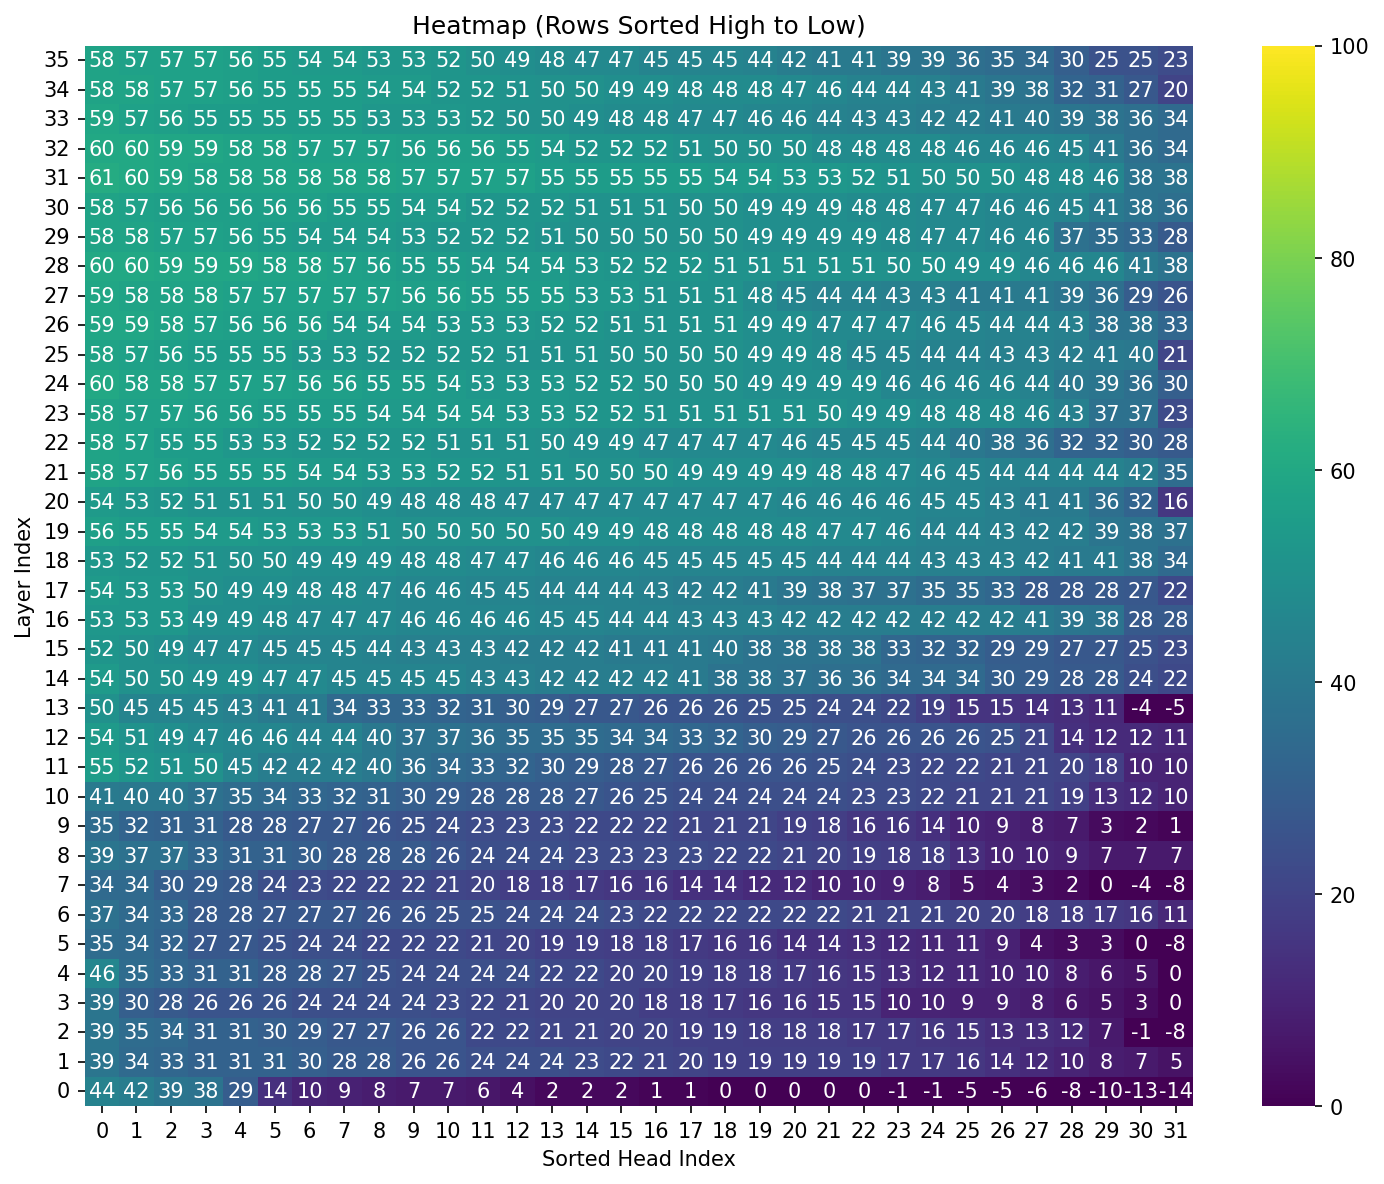

Top 10 (layer, head):
(31, 19) score= 0.6141
(28, 21) score= 0.6084
(31, 18) score= 0.6071
(28, 23) score= 0.6053
(24, 26) score= 0.6043
(32, 12) score= 0.6034
(32, 16) score= 0.6022
(28, 22) score= 0.5971
(28, 20) score= 0.595
(32, 4) score= 0.5949
Best-head train-set Spearman rho: 0.7071


In [3]:
def build_vision_prompt(image_path: str):
    # Keep text generic so the model must rely on portrait cues instead of biography facts.
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": "What's his/her position on US politics?"},
        ],
    }]
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

prompts = [build_vision_prompt(p) for p in df_probe["image_path"].values]
labels = df_probe["nominate_dim1"].astype(float).values

print("Prepared prompts:", len(prompts))
print("Label range:", float(np.min(labels)), "to", float(np.max(labels)))
PREFIX = "portrait_ideology"

ax, performance, ridge_models = probe_heads(
    model_path=MODEL_PATH,
    model=model,
    prompts=prompts,
    labels=labels,
    prefix=PREFIX,
    alpha=1.0,
    n_splits=2,
    seed=SEED,
    data_dir="results",
    figsize=(10, 8),
    dpi=150,
    cmap="viridis",
    vmin=0,
    vmax=100,
    mode="vision",
    device=device,
)

from scipy.stats import spearmanr

# Inspect strongest heads
top_idx = topk_head_indices(performance, k=10)
print("Top 10 (layer, head):")
for li, hi in top_idx.tolist():
    print((li, hi), "score=", round(float(performance[li, hi]), 4))

# Simple train-set sanity check using the single best head
ridge_models, _ = load_ridge_models(MODEL_PATH, PREFIX)
best_l, best_h = top_idx[0].tolist()

# Load saved features to verify direct correlation on available examples
import pickle
base_name = MODEL_PATH.split("/")[-1].lower()
feat_path = f"results/{base_name}/{PREFIX}_features.pkl"
features, y = pickle.load(open(feat_path, "rb"))
pred = ridge_models[int(best_l)][int(best_h)].predict(features[:, 0, int(best_l), int(best_h), :])
rho = spearmanr(y, pred).statistic
print("Best-head train-set Spearman rho:", round(float(rho), 4))

In [4]:
import pickle
from utils import load_ridge_models, topk_head_indices, compute_combined_coefs, generate_with_head_intervention_gpu

PREFIX = "portrait_ideology"

# Rebuild steering direction from the portrait probe
ridge_models, performance = load_ridge_models(MODEL_PATH, PREFIX)
top_idx = topk_head_indices(performance, k=32)

base_name = MODEL_PATH.split("/")[-1].lower()
feat_path = f"results/{base_name}/{PREFIX}_features.pkl"
features, _ = pickle.load(open(feat_path, "rb"))
combined_coefs = compute_combined_coefs(
    feats=features,
    ridge_models=ridge_models,
    top_idx=top_idx,
    device=device,
)

def make_chat_prompt(text: str) -> str:
    messages = [{
        "role": "user",
        "content": [{"type": "text", "text": text}],
    }]
    return processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

topics = [
    "As a US politician, what's your position on immigration policy.",
    "As a US politician, what's your position on abortion policy.",
    "As a US politician, what's your position on gun control policy.",
]

chat_prompts = [make_chat_prompt(t) for t in topics]

# Sign convention: nominate_dim1 is typically liberal<0, conservative>0.
outputs_liberal = generate_with_head_intervention_gpu(
    model=model,
    tokenizer=processor.tokenizer,
    prompts=chat_prompts,
    alpha=-100.0,
    max_new_tokens=120,
    combined_coefs=combined_coefs,
    device=device,
    mode="qwen3-vl",
)

outputs_conservative = generate_with_head_intervention_gpu(
    model=model,
    tokenizer=processor.tokenizer,
    prompts=chat_prompts,
    alpha=100.0,
    max_new_tokens=120,
    combined_coefs=combined_coefs,
    device=device,
    mode="qwen3-vl",
)

for i, prompt in enumerate(topics, 1):
    print("=" * 100)
    print(f"Prompt {i}: {prompt}")
    print("\n[Liberal steering]")
    print(outputs_liberal[i - 1])
    print("\n[Conservative steering]")
    print(outputs_conservative[i - 1])
    print()

Prompt 1: As a US politician, what's your position on immigration policy.

[Liberal steering]
user
As a US politician, what's your position on immigration policy.
assistant
As a U.S. politician, my position on immigration policy is rooted in fairness, opportunity, and national security — with a strong emphasis on reforming the system to be more transparent, equitable, and effective.

I believe in a comprehensive immigration policy that:

1. **Cleans up the legal system** — including a fair and efficient process for obtaining legal status, especially for those already here with legal residence or work authorization.

2. **Cuts back on loopholes and backdoors** — ensuring that immigration policies are not exploited by unauthorized operations or loopholes that allow individuals to evade legal requirements.

[Conservative steering]
user
As a US politician, what's your position on immigration policy.
assistant
As a US politician, my position on immigration policy is rooted in the principles

In [5]:
# Llama steering using existing politician probe from results/llama-3.1-8b-instruct
import gc
import pickle
from transformers import AutoModelForCausalLM, AutoTokenizer
from utils import load_ridge_models, topk_head_indices, compute_combined_coefs, generate_with_head_intervention_gpu

# Free VRAM from Qwen3-VL if still loaded
try:
    del model
except Exception:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

LLAMA_MODEL_PATH = "/project/jevans/tzhang3/models/Llama-3.1-8B-Instruct"
LLAMA_PREFIX = "politician"

# Reuse same prompts if available; otherwise default to immigration prompt.
if "topics" in globals() and isinstance(topics, list) and len(topics) > 0:
    llama_topics = topics
else:
    llama_topics = ["As a US politician, what's your position on immigration policy."]

llama_tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_PATH)
if llama_tokenizer.pad_token is None:
    llama_tokenizer.pad_token = llama_tokenizer.eos_token

def make_llama_chat_prompt(text: str) -> str:
    if hasattr(llama_tokenizer, "apply_chat_template") and llama_tokenizer.chat_template is not None:
        msgs = [{"role": "user", "content": text}]
        return llama_tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    return f"USER: {text}\nASSISTANT:"

llama_prompts = [make_llama_chat_prompt(t) for t in llama_topics]

llama_ridge_models, llama_performance = load_ridge_models(LLAMA_MODEL_PATH, LLAMA_PREFIX)
llama_top_idx = topk_head_indices(llama_performance, k=16)

llama_base_name = LLAMA_MODEL_PATH.split("/")[-1].lower()
llama_feat_path = f"results/{llama_base_name}/{LLAMA_PREFIX}_features.pkl"
llama_features, _ = pickle.load(open(llama_feat_path, "rb"))

llama_combined_coefs = compute_combined_coefs(
    feats=llama_features,
    ridge_models=llama_ridge_models,
    top_idx=llama_top_idx,
    device=device,
)

llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_PATH,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

llama_outputs_liberal = generate_with_head_intervention_gpu(
    model=llama_model,
    tokenizer=llama_tokenizer,
    prompts=llama_prompts,
    alpha=-15.0,
    max_new_tokens=120,
    combined_coefs=llama_combined_coefs,
    device=device,
    mode="text",
)

llama_outputs_conservative = generate_with_head_intervention_gpu(
    model=llama_model,
    tokenizer=llama_tokenizer,
    prompts=llama_prompts,
    alpha=15.0,
    max_new_tokens=120,
    combined_coefs=llama_combined_coefs,
    device=device,
    mode="text",
)

for i, prompt in enumerate(llama_topics, 1):
    print("=" * 100)
    print(f"Prompt {i}: {prompt}")
    print("\n[Llama liberal steering | alpha=-15.0]")
    print(llama_outputs_liberal[i - 1])
    print("\n[Llama conservative steering | alpha=+15.0]")
    print(llama_outputs_conservative[i - 1])
    print()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Prompt 1: As a US politician, what's your position on immigration policy.

[Llama liberal steering | alpha=-15.0]
system

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

user

As a US politician, what's your position on immigration policy.assistant

As a US politician, I believe that immigration policy should be a comprehensive and inclusive approach that balances the need for economic growth, national security, and humanitarian concerns. Here's a summary of my position:

**Key Principles:**

1.  **Family Unity**: I believe that family unity is a fundamental value that should be at the heart of our immigration policy. I support a pathway to citizenship for undocumented immigrants who have been living in the US for years, have a clean record, and have contributed to our society in meaningful ways.
2.  **Economic Growth**: Immigration has been a driving force

[Llama conservative steering | alpha=+15.0]
system

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024


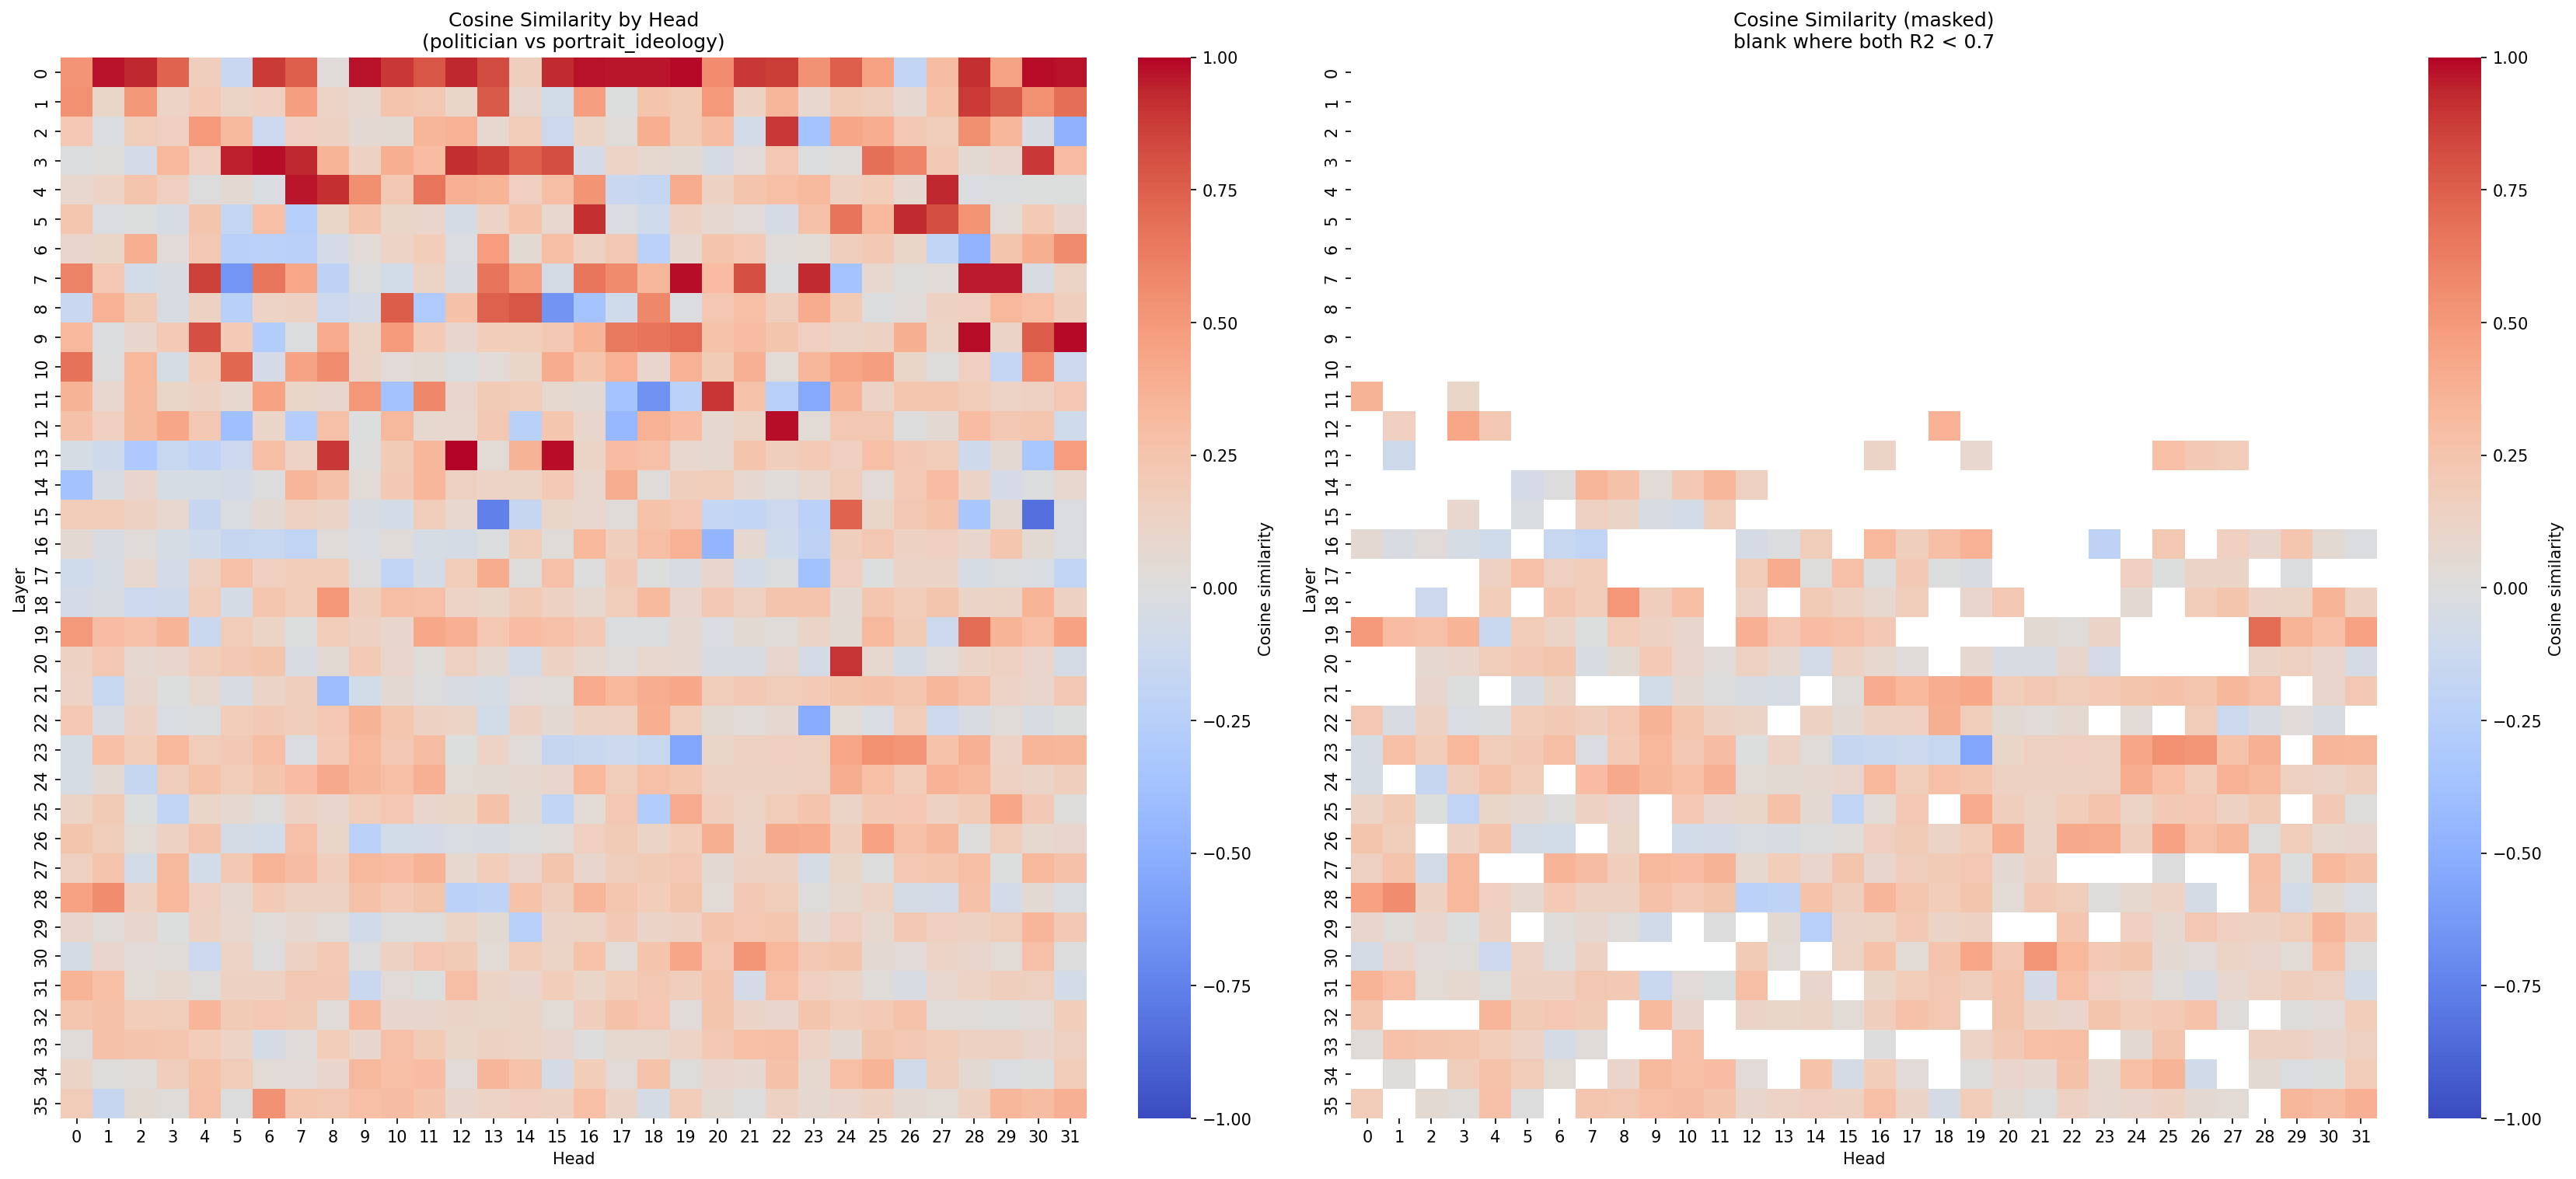

All-head cosine: min=-0.8303 max=0.9945 mean=0.1718
Kept after mask: 545/1152 heads (47.3%)


In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import load_ridge_models

if "MODEL_PATH" not in globals():
    MODEL_PATH = "/home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct"

def build_all_head_directions(model_path: str, prefix: str):
    ridge_models, performance = load_ridge_models(model_path, prefix)
    base_name = model_path.split("/")[-1].lower()
    feat_path = f"results/{base_name}/{prefix}_features.pkl"
    feats, _ = pickle.load(open(feat_path, "rb"))  # [N, T, L, H, D]

    # Match steering direction scaling used in utils.compute_combined_coefs: coef * std.
    std_tensor = np.std(feats[:, 0], axis=0)  # [L, H, D]
    L, H, D = std_tensor.shape
    directions = np.zeros((L, H, D), dtype=np.float32)

    for li in range(L):
        for hi in range(H):
            directions[li, hi] = np.asarray(ridge_models[li][hi].coef_, dtype=np.float32) * std_tensor[li, hi]

    return directions, np.asarray(performance, dtype=np.float32)

# Load both probe directions
politician_dirs, politician_r2 = build_all_head_directions(MODEL_PATH, "politician")
portrait_dirs, portrait_r2 = build_all_head_directions(MODEL_PATH, "portrait_ideology")

if politician_dirs.shape != portrait_dirs.shape:
    raise ValueError(f"Shape mismatch: politician {politician_dirs.shape} vs portrait {portrait_dirs.shape}")

# Per-head cosine similarity across the D dimension
eps = 1e-12
dot = np.sum(politician_dirs * portrait_dirs, axis=-1)
norms = np.linalg.norm(politician_dirs, axis=-1) * np.linalg.norm(portrait_dirs, axis=-1)
cos_sim = dot / np.maximum(norms, eps)  # [L, H]

# Mask heads where either probe has weak fit
r2_threshold = 0.7
valid_mask = (politician_r2 >= r2_threshold) | (portrait_r2 >= r2_threshold)
cos_sim_masked = np.where(valid_mask, cos_sim, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(22, 10), dpi=150, constrained_layout=True)

sns.heatmap(
    cos_sim,
    ax=axes[0],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"label": "Cosine similarity"},
)
axes[0].set_title("Cosine Similarity by Head\n(politician vs portrait_ideology)")
axes[0].set_xlabel("Head")
axes[0].set_ylabel("Layer")

sns.heatmap(
    cos_sim_masked,
    ax=axes[1],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"label": "Cosine similarity"},
)
axes[1].set_title(f"Cosine Similarity (masked)\nblank where both R2 < {r2_threshold}")
axes[1].set_xlabel("Head")
axes[1].set_ylabel("Layer")

plt.show()

print("All-head cosine: min=%.4f max=%.4f mean=%.4f" % (np.nanmin(cos_sim), np.nanmax(cos_sim), np.nanmean(cos_sim)))
print("Kept after mask: %d/%d heads (%.1f%%)" % (valid_mask.sum(), valid_mask.size, 100.0 * valid_mask.mean()))

  0%|          | 0/10 [00:00<?, ?it/s]

,prompt_id,num_scored_tokens,pearson_corr
0,1,120,0.250018
1,2,120,0.286900
2,3,120,-0.153825
3,4,120,0.179964
4,5,120,0.445581
5,6,120,0.148956
6,7,120,0.401485
7,8,120,0.290119
8,9,120,0.095631
9,10,120,0.255411


Global token-level Pearson correlation: 0.4067
Co-firing probe metric (mean prompt-wise Pearson): 0.2200


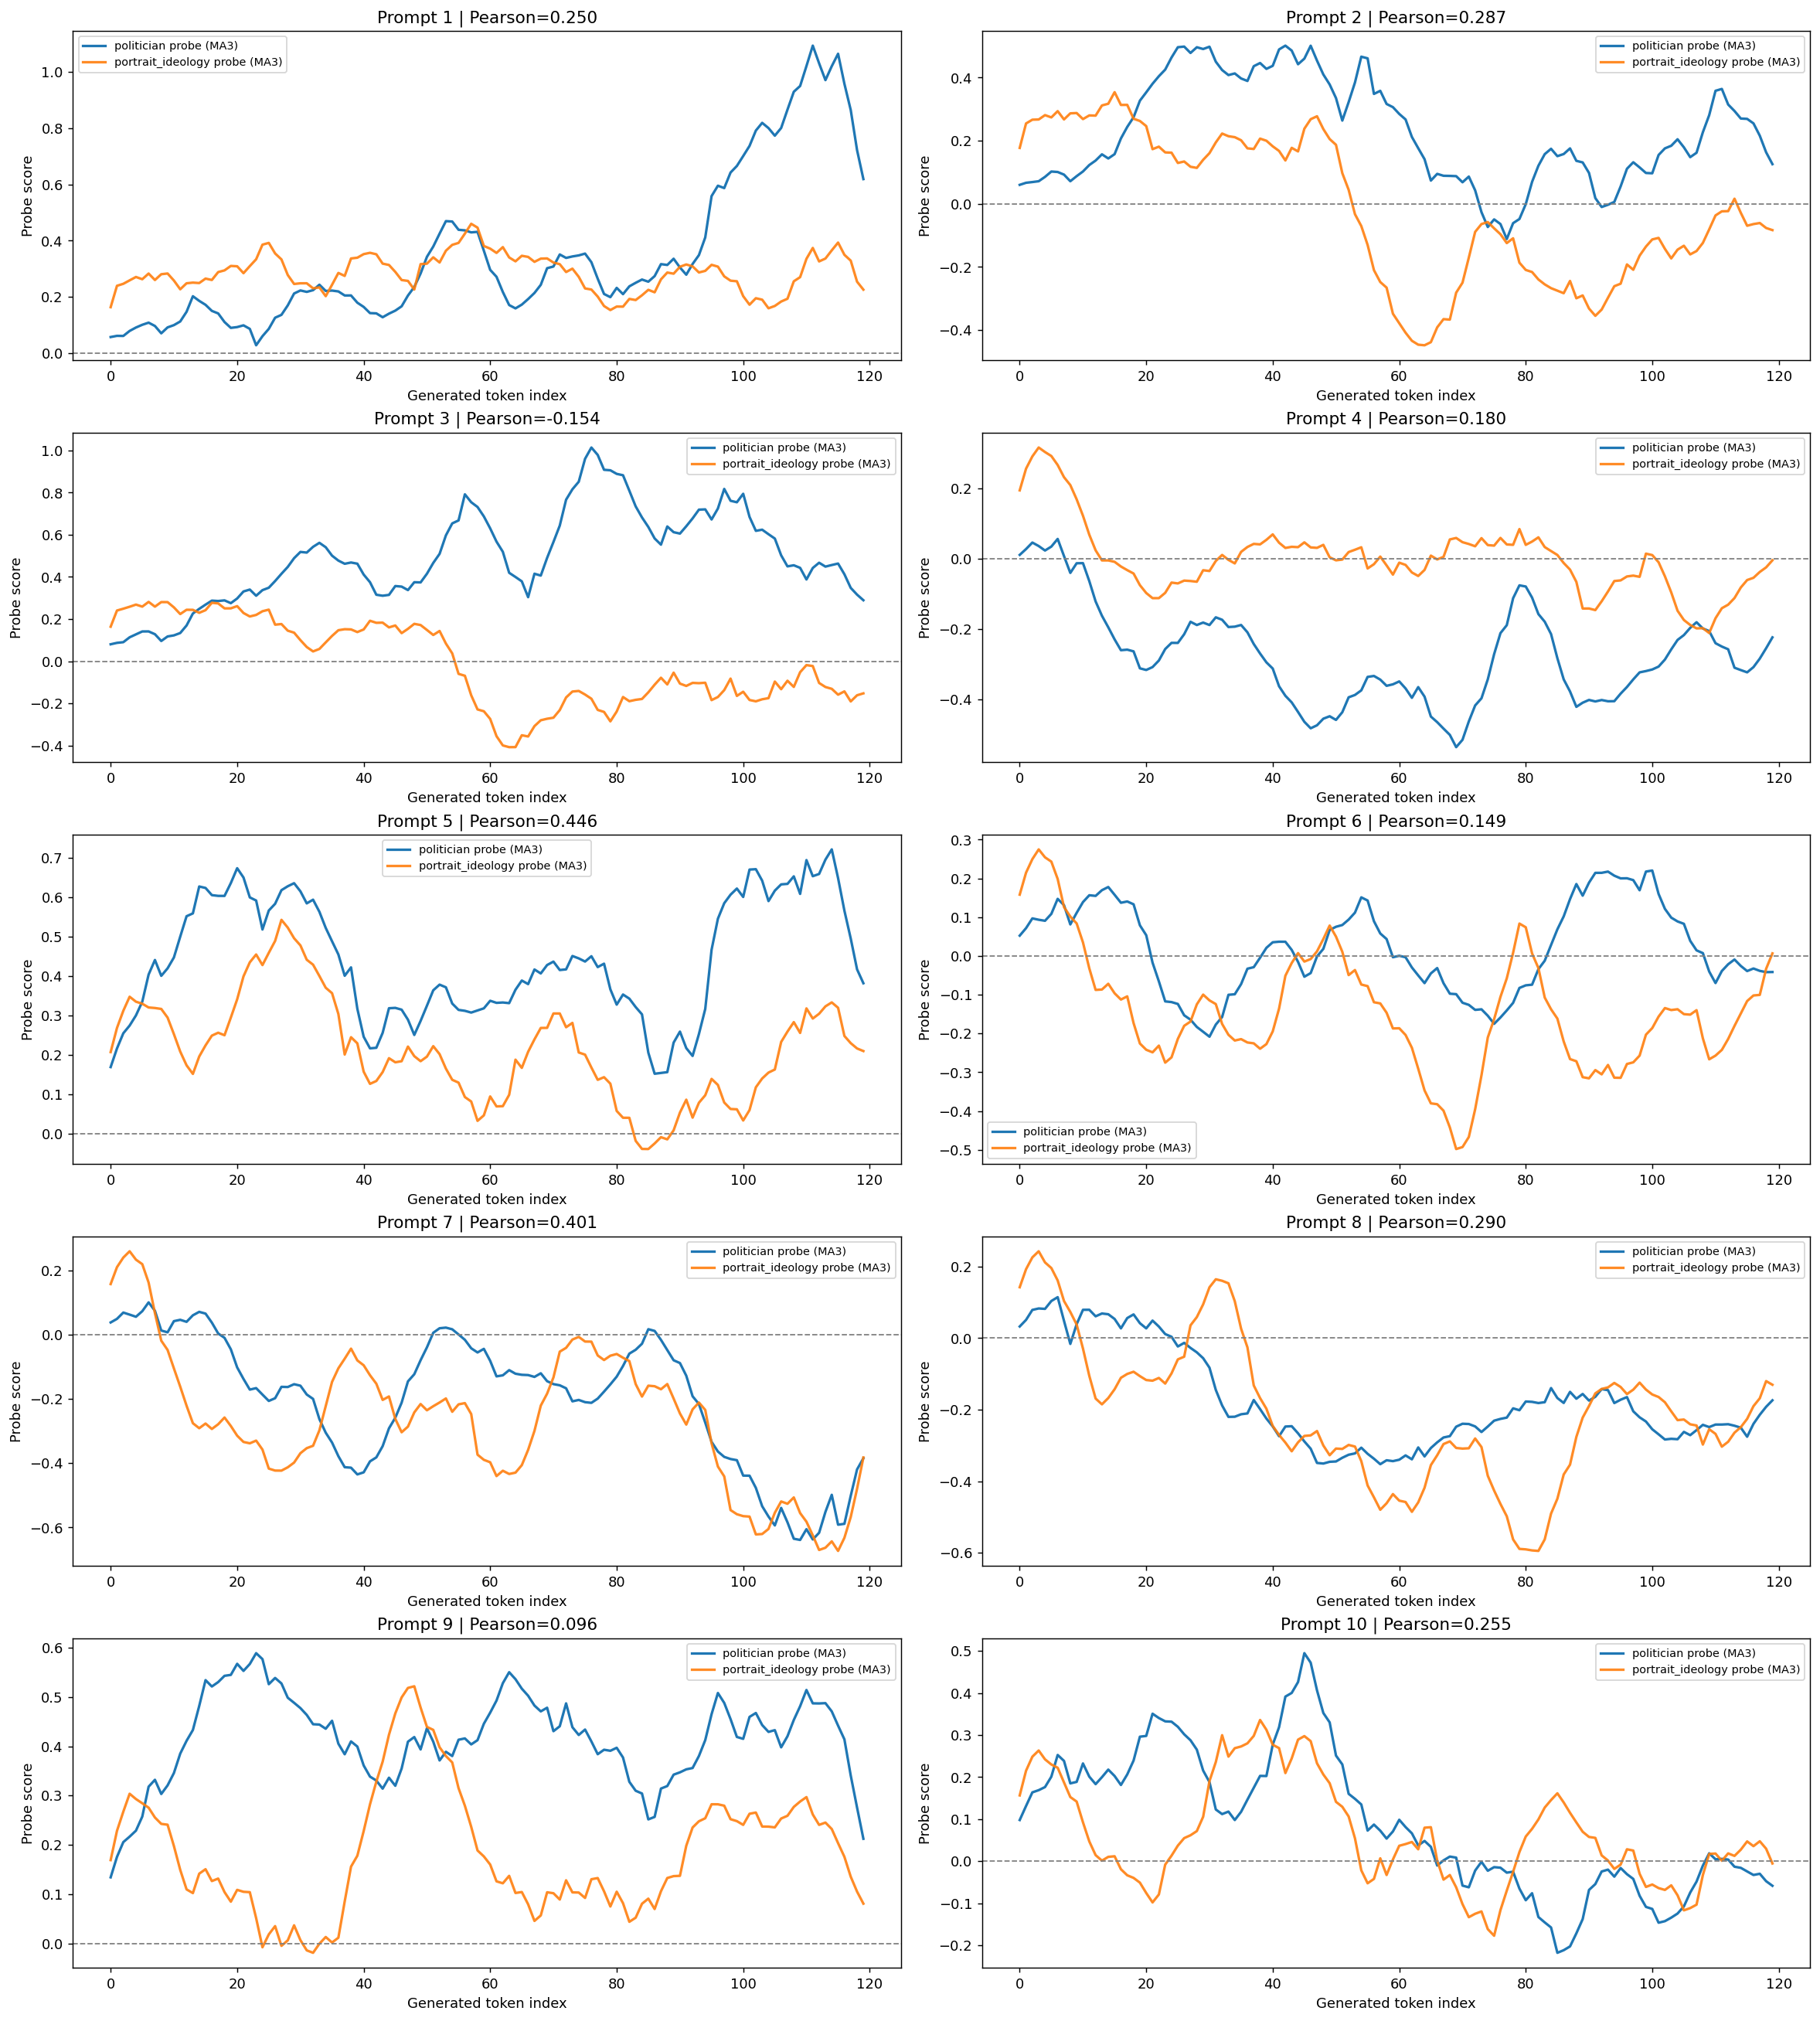

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from utils import load_ridge_models, topk_head_indices, extract_head_out_per_token

if "model" not in globals() or "processor" not in globals():
    raise RuntimeError("Run the model/processor load cell first.")
if "MODEL_PATH" not in globals():
    MODEL_PATH = "/home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct"

def build_text_probe_prompt(text: str):
    messages = [{
        "role": "user",
        "content": [{"type": "text", "text": text}],
    }]
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

cofiring_prompts = [
    "As a U.S. politician, what is your position on immigration policy?",
    "As a U.S. politician, what is your position on abortion policy?",
    "As a U.S. politician, what is your position on gun control policy?",
    "As a U.S. politician, what is your position on climate policy?",
    "As a U.S. politician, what is your position on federal taxation?",
    "As a U.S. politician, what is your position on healthcare reform?",
    "As a U.S. politician, what is your position on voting rights policy?",
    "As a U.S. politician, what is your position on labor unions?",
    "As a U.S. politician, what is your position on military spending?",
    "As a U.S. politician, what is your position on public education funding?",
]

encoded_prompts = [build_text_probe_prompt(p) for p in cofiring_prompts]

token_results = extract_head_out_per_token(
    model=model,
    tokenizer=processor.tokenizer,
    prompts=encoded_prompts,
    max_new_tokens=120,
    output_only=True,
    device=device if "device" in globals() else None,
    mode="vision",
)

def score_tokens_with_prefix(results, model_path: str, prefix: str, k: int = 32):
    ridge_models, performance = load_ridge_models(model_path, prefix)
    top_idx = topk_head_indices(performance, k=k)
    if hasattr(top_idx, "detach"):
        top_idx = top_idx.detach().cpu().numpy()

    all_scores = []
    for res in results:
        feats = res["features"]  # [T, L, H, D]
        if feats.size == 0:
            all_scores.append(np.array([], dtype=np.float32))
            continue

        token_scores = np.zeros(feats.shape[0], dtype=np.float32)
        for t in range(feats.shape[0]):
            head_vals = []
            for li, hi in top_idx:
                x = feats[t, int(li), int(hi), :].reshape(1, -1)
                head_vals.append(float(ridge_models[int(li)][int(hi)].predict(x)[0]))
            token_scores[t] = float(np.mean(head_vals)) if len(head_vals) > 0 else np.nan

        all_scores.append(token_scores)

    return all_scores

def moving_average_1d(x, window: int = 3):
    x = np.asarray(x, dtype=np.float32)
    if x.size == 0 or window <= 1 or x.size < window:
        return x
    kernel = np.ones(window, dtype=np.float32) / float(window)
    return np.convolve(x, kernel, mode="same")

politician_scores = score_tokens_with_prefix(token_results, MODEL_PATH, "politician", k=16)
portrait_scores = score_tokens_with_prefix(token_results, MODEL_PATH, "portrait_ideology", k=16)

rows = []
all_pol = []
all_por = []

for i, (s_pol, s_por) in enumerate(zip(politician_scores, portrait_scores), start=1):
    n = min(len(s_pol), len(s_por))
    if n < 2:
        corr = np.nan
    else:
        try:
            corr = float(pearsonr(s_pol[:n], s_por[:n]).statistic)
        except Exception:
            corr = np.nan

    rows.append({
        "prompt_id": i,
        "num_scored_tokens": int(n),
        "pearson_corr": corr,
    })

    if n > 0:
        all_pol.append(s_pol[:n])
        all_por.append(s_por[:n])

corr_df = pd.DataFrame(rows)
display(corr_df)

if len(all_pol) > 0 and np.concatenate(all_pol).size >= 2:
    global_corr = float(pearsonr(np.concatenate(all_pol), np.concatenate(all_por)).statistic)
else:
    global_corr = np.nan

co_firing_metric = float(np.nanmean(corr_df["pearson_corr"]))

print(f"Global token-level Pearson correlation: {global_corr:.4f}")
print(f"Co-firing probe metric (mean prompt-wise Pearson): {co_firing_metric:.4f}")

fig, axes = plt.subplots(5, 2, figsize=(18, 20), dpi=130, constrained_layout=True)
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx >= len(cofiring_prompts):
        ax.axis("off")
        continue

    s_pol = politician_scores[idx]
    s_por = portrait_scores[idx]
    n = min(len(s_pol), len(s_por))

    if n == 0:
        ax.text(0.5, 0.5, "No scored tokens", ha="center", va="center")
        ax.set_title(f"Prompt {idx + 1}")
        ax.axis("off")
        continue

    x = np.arange(n)
    s_pol_ma3 = moving_average_1d(s_pol[:n], window=10)
    s_por_ma3 = moving_average_1d(s_por[:n], window=10)

    ax.plot(x, s_pol_ma3, label="politician probe (MA3)", linewidth=1.8)
    ax.plot(x, s_por_ma3, label="portrait_ideology probe (MA3)", linewidth=1.8, alpha=0.9)
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
    ax.set_title(f"Prompt {idx + 1} | Pearson={corr_df.loc[idx, 'pearson_corr']:.3f}")
    ax.set_xlabel("Generated token index")
    ax.set_ylabel("Probe score")
    ax.legend(loc="best", fontsize=8)

plt.show()

## Vision+Text probing

Prepared prompts: 550
Label range: -0.797 to 0.891


Extracting features:   0%|          | 0/550 [00:00<?, ?it/s]

Saved features and labels to results/qwen3-vl-8b-instruct/combined_ideology_features.pkl


Layers:   0%|          | 0/36 [00:00<?, ?it/s]

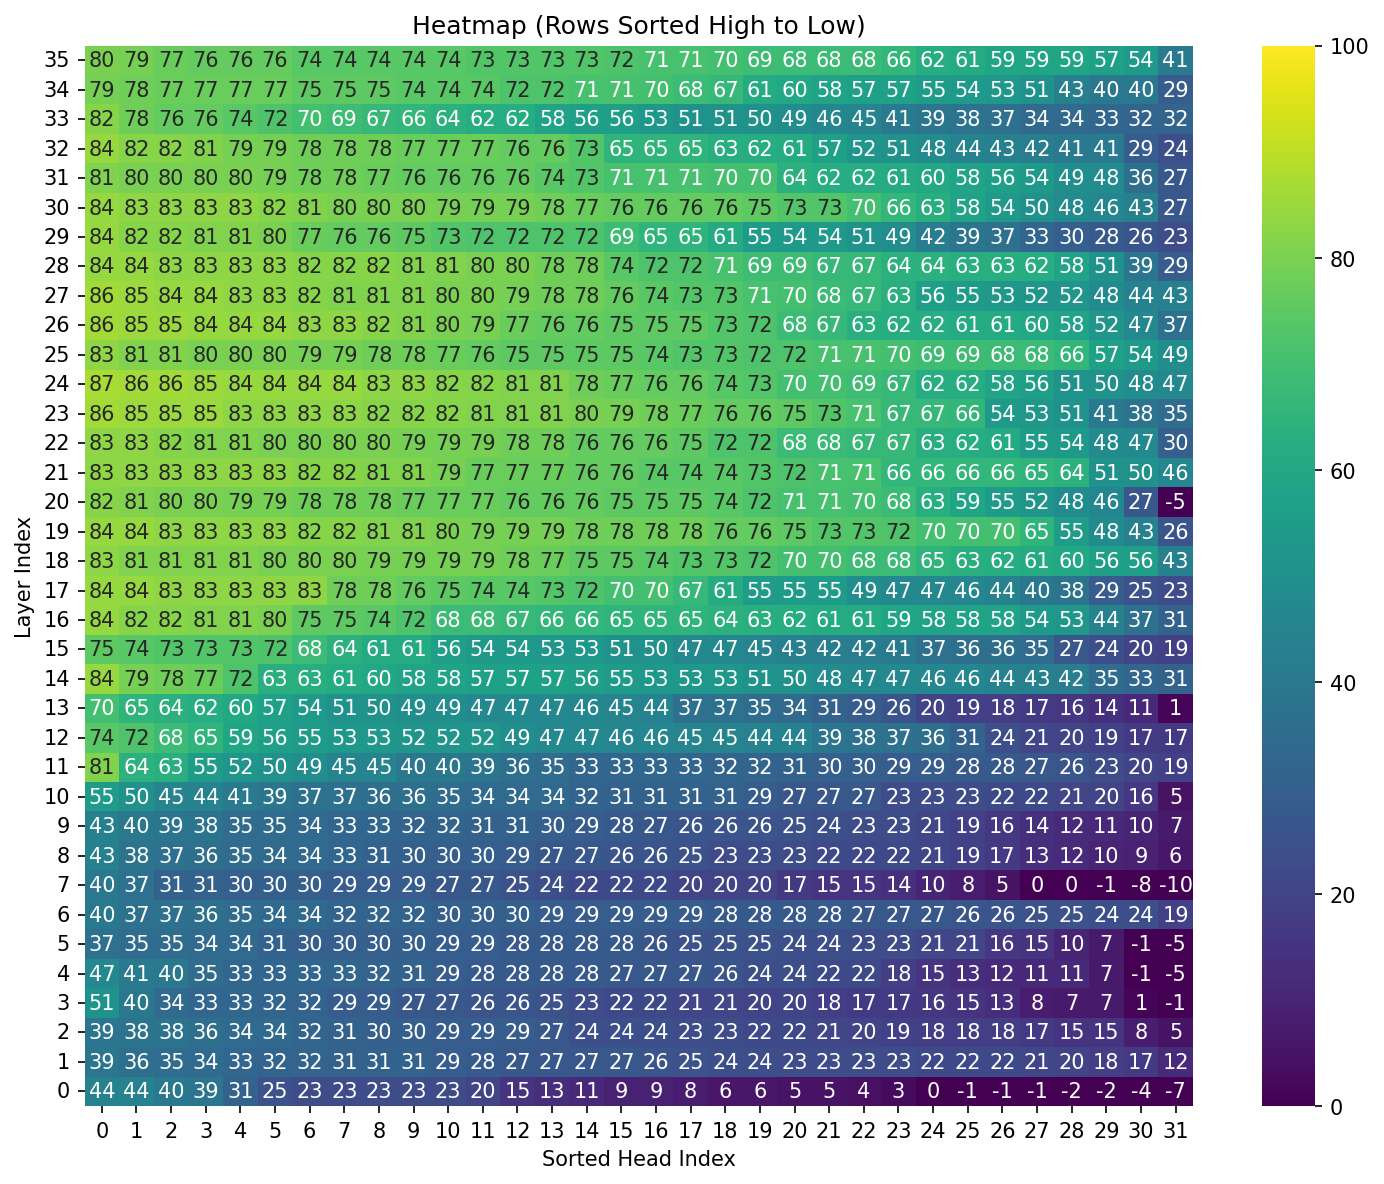

Top 10 (layer, head):
(24, 24) score= 0.8711
(24, 26) score= 0.8649
(27, 29) score= 0.8647
(23, 10) score= 0.8627
(24, 27) score= 0.8617
(26, 25) score= 0.8605
(24, 25) score= 0.8594
(23, 11) score= 0.8586
(26, 24) score= 0.8579
(26, 26) score= 0.8564
Best-head train-set Spearman rho: 0.8806


In [4]:
def build_vision_prompt(image_path: str, politician_name: str):
    # Include politician name in text so this probing variant conditions on identity + portrait.
    name = str(politician_name).strip() if politician_name is not None else ""
    if not name:
        name = "this politician"
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": f"What would {name} say in a policy interview?"},
        ],
    }]
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

prompts = [
    build_vision_prompt(image_path, politician_name)
    for image_path, politician_name in zip(df_probe["image_path"].values, df_probe["name"].values)
]
labels = df_probe["nominate_dim1"].astype(float).values

print("Prepared prompts:", len(prompts))
print("Label range:", float(np.min(labels)), "to", float(np.max(labels)))
PREFIX = "combined_ideology"

ax, performance, ridge_models = probe_heads(
    model_path=MODEL_PATH,
    model=model,
    prompts=prompts,
    labels=labels,
    prefix=PREFIX,
    alpha=1.0,
    n_splits=2,
    seed=SEED,
    data_dir="results",
    figsize=(10, 8),
    dpi=150,
    cmap="viridis",
    vmin=0,
    vmax=100,
    mode="vision",
    device=device,
)

from scipy.stats import spearmanr

# Inspect strongest heads
top_idx = topk_head_indices(performance, k=10)
print("Top 10 (layer, head):")
for li, hi in top_idx.tolist():
    print((li, hi), "score=", round(float(performance[li, hi]), 4))

# Simple train-set sanity check using the single best head
ridge_models, _ = load_ridge_models(MODEL_PATH, PREFIX)
best_l, best_h = top_idx[0].tolist()

# Load saved features to verify direct correlation on available examples
import pickle
base_name = MODEL_PATH.split("/")[-1].lower()
feat_path = f"results/{base_name}/{PREFIX}_features.pkl"
features, y = pickle.load(open(feat_path, "rb"))
pred = ridge_models[int(best_l)][int(best_h)].predict(features[:, 0, int(best_l), int(best_h), :])
rho = spearmanr(y, pred).statistic
print("Best-head train-set Spearman rho:", round(float(rho), 4))

Prepared prompts: 550
Label range: -0.797 to 0.891


Extracting features:   0%|          | 0/550 [00:00<?, ?it/s]

Saved features and labels to results/qwen3-vl-8b-instruct/textual_ideology_features.pkl


Layers:   0%|          | 0/36 [00:00<?, ?it/s]

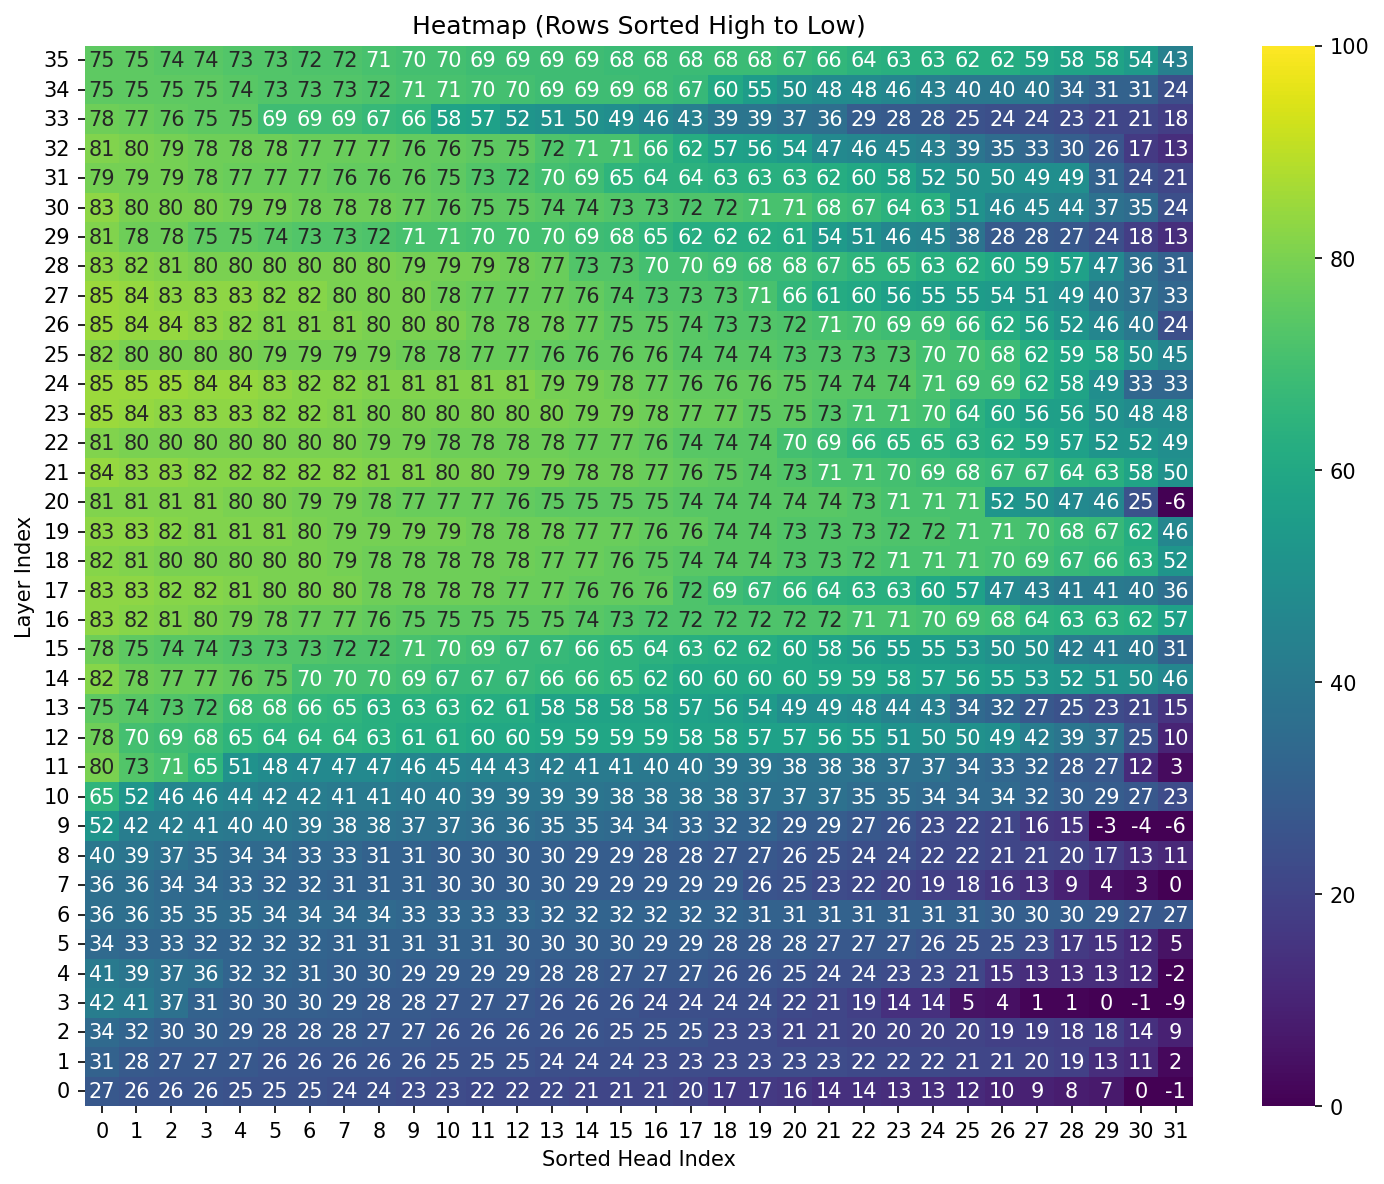

Top 10 (layer, head):
(24, 24) score= 0.8576
(24, 25) score= 0.8556
(24, 27) score= 0.8553
(26, 25) score= 0.8538
(27, 29) score= 0.8522
(23, 10) score= 0.8501
(26, 24) score= 0.8492
(27, 28) score= 0.8486
(24, 26) score= 0.8473
(26, 27) score= 0.8464
Best-head train-set Spearman rho: 0.8688


In [5]:
def build_vision_prompt(image_path: str, politician_name: str):
    # Include politician name in text so this probing variant conditions on identity + portrait.
    name = str(politician_name).strip() if politician_name is not None else ""
    if not name:
        name = "this politician"
    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": f"What would {name} say in a policy interview?"},
        ],
    }]
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

prompts = [
    build_vision_prompt(image_path, politician_name)
    for image_path, politician_name in zip(df_probe["image_path"].values, df_probe["name"].values)
]
labels = df_probe["nominate_dim1"].astype(float).values

print("Prepared prompts:", len(prompts))
print("Label range:", float(np.min(labels)), "to", float(np.max(labels)))
PREFIX = "textual_ideology"

ax, performance, ridge_models = probe_heads(
    model_path=MODEL_PATH,
    model=model,
    prompts=prompts,
    labels=labels,
    prefix=PREFIX,
    alpha=1.0,
    n_splits=2,
    seed=SEED,
    data_dir="results",
    figsize=(10, 8),
    dpi=150,
    cmap="viridis",
    vmin=0,
    vmax=100,
    mode="vision",
    device=device,
)

from scipy.stats import spearmanr

# Inspect strongest heads
top_idx = topk_head_indices(performance, k=10)
print("Top 10 (layer, head):")
for li, hi in top_idx.tolist():
    print((li, hi), "score=", round(float(performance[li, hi]), 4))

# Simple train-set sanity check using the single best head
ridge_models, _ = load_ridge_models(MODEL_PATH, PREFIX)
best_l, best_h = top_idx[0].tolist()

# Load saved features to verify direct correlation on available examples
import pickle
base_name = MODEL_PATH.split("/")[-1].lower()
feat_path = f"results/{base_name}/{PREFIX}_features.pkl"
features, y = pickle.load(open(feat_path, "rb"))
pred = ridge_models[int(best_l)][int(best_h)].predict(features[:, 0, int(best_l), int(best_h), :])
rho = spearmanr(y, pred).statistic
print("Best-head train-set Spearman rho:", round(float(rho), 4))

## Classify image tokens from Congress

In [6]:
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

from utils import generate_and_score_tokens

if "model" not in globals() or "processor" not in globals():
    raise RuntimeError("Run the model/processor load cell first.")
if "df_probe" not in globals():
    raise RuntimeError("Run the data preparation cells first.")


def vision_grid_hw(orig_h: int, orig_w: int, processor):
    ip = processor.image_processor
    min_pixels = ip.size["shortest_edge"]
    max_pixels = ip.size["longest_edge"]
    patch = ip.patch_size
    merge = ip.merge_size

    factor = patch * merge
    resized_h, resized_w = smart_resize(orig_h, orig_w, factor, min_pixels=min_pixels, max_pixels=max_pixels)
    grid_h = (resized_h // patch) // merge
    grid_w = (resized_w // patch) // merge
    return int(grid_h), int(grid_w)


def _try_get_image_pad_id(tokenizer):
    for tok in ["<|image_pad|>"]:
        tid = tokenizer.convert_tokens_to_ids(tok)
        if tid is not None and tid != tokenizer.unk_token_id:
            return tid
    return None


def extract_image_token_scores(token_ids, scores, tokenizer):
    token_ids = np.asarray(token_ids).squeeze()
    scores = np.asarray(scores).squeeze()

    if len(token_ids) == len(scores) + 1:
        token_ids = token_ids[:-1]

    image_pad_id = _try_get_image_pad_id(tokenizer)
    if image_pad_id is None:
        raise RuntimeError("Could not find the image pad token in the tokenizer.")

    image_idx = np.where(token_ids == image_pad_id)[0]
    return scores[image_idx], image_idx


RESIZED_IMAGE_WIDTH = 250
RESAMPLE_LANCZOS = getattr(Image, "Resampling", Image).LANCZOS
RIDGE_PREFIX = "politician"
TOP_K = 16
MAX_NEW_TOKENS = 1
PARTY_MAP = {100: "Democrat", 200: "Republican"}


def load_resized_portrait(image_path: str, target_width: int = RESIZED_IMAGE_WIDTH):
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        if image.width > target_width:
            target_height = max(1, round(image.height * target_width / image.width))
            image = image.resize((target_width, target_height), RESAMPLE_LANCZOS)
        return image


def build_congress_token_prompt(image):
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What's his/her position on US politics?"},
        ],
    }]
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )


portrait_inputs = []
for row in df_probe.itertuples(index=False):
    resized_image = load_resized_portrait(row.image_path)
    grid_h, grid_w = vision_grid_hw(resized_image.height, resized_image.width, processor)
    portrait_inputs.append(
        {
            "bioguide": row.bioguide,
            "name": row.name,
            "party_code": int(row.party_code),
            "nominate_dim1": float(row.nominate_dim1),
            "image_path": row.image_path,
            "resized_width": int(resized_image.width),
            "resized_height": int(resized_image.height),
            "grid_shape": (grid_h, grid_w),
            "prompt": build_congress_token_prompt(resized_image),
        }
    )

congress_token_results = generate_and_score_tokens(
    model_path=MODEL_PATH,
    prompts=[record["prompt"] for record in portrait_inputs],
    model=model,
    tokenizer=processor.tokenizer,
    max_new_tokens=MAX_NEW_TOKENS,
    k=TOP_K,
    ridge_prefix=RIDGE_PREFIX,
    output_only=False,
    visualize=False,
    mode="vision",
    device=device,
)

portrait_token_maps = []
summary_rows = []

for record, result in zip(portrait_inputs, congress_token_results):
    grid_h, grid_w = record["grid_shape"]
    expected_tokens = grid_h * grid_w

    image_scores, image_token_idx = extract_image_token_scores(
        result["token_ids"],
        result["scores"],
        processor.tokenizer,
    )

    if len(image_scores) != expected_tokens:
        print(
            f"Skipping {record['bioguide']}: expected {expected_tokens} image tokens but found {len(image_scores)}"
        )
        continue

    party = PARTY_MAP.get(record["party_code"], f"Other ({record['party_code']})")
    heatmap = image_scores.reshape(grid_h, grid_w)

    portrait_token_maps.append(
        {
            "bioguide": record["bioguide"],
            "name": record["name"],
            "party": party,
            "party_code": record["party_code"],
            "nominate_dim1": record["nominate_dim1"],
            "image_path": record["image_path"],
            "resized_width": record["resized_width"],
            "resized_height": record["resized_height"],
            "grid_shape": (grid_h, grid_w),
            "num_image_tokens": int(expected_tokens),
            "image_token_indices": image_token_idx,
            "image_token_scores": image_scores,
            "heatmap": heatmap,
        }
    )

    summary_rows.append(
        {
            "bioguide": record["bioguide"],
            "name": record["name"],
            "party": party,
            "party_code": record["party_code"],
            "nominate_dim1": record["nominate_dim1"],
            "resized_width": record["resized_width"],
            "resized_height": record["resized_height"],
            "grid_h": int(grid_h),
            "grid_w": int(grid_w),
            "num_image_tokens": int(expected_tokens),
            "mean_image_token_score": float(np.mean(image_scores)),
            "median_image_token_score": float(np.median(image_scores)),
            "mean_abs_image_token_score": float(np.mean(np.abs(image_scores))),
            "min_image_token_score": float(np.min(image_scores)),
            "max_image_token_score": float(np.max(image_scores)),
        }
    )

congress_token_scores = pd.DataFrame(summary_rows)

print(f"Scored portraits: {len(congress_token_scores)} (max portrait width {RESIZED_IMAGE_WIDTH}px)")
print("Party counts:")
display(congress_token_scores["party"].value_counts().rename("count").to_frame())
display(congress_token_scores.head())

  0%|          | 0/550 [00:00<?, ?it/s]

Scored portraits: 550 (max portrait width 250px)
Party counts:


,count
party,
Democrat,285
Republican,262
Other (328),3


,bioguide,name,party,party_code,nominate_dim1,resized_width,resized_height,grid_h,grid_w,num_image_tokens,mean_image_token_score,median_image_token_score,mean_abs_image_token_score,min_image_token_score,max_image_token_score
0,R000575,Mike Rogers,Republican,200,0.377,250,306,10,8,80,-0.090102,-0.139303,0.210692,-0.522635,0.465791
1,S001185,Terri A. Sewell,Democrat,100,-0.398,250,306,10,8,80,-0.397974,-0.370417,0.398884,-0.956248,0.023399
2,R000591,Martha Roby,Republican,200,0.362,250,306,10,8,80,-0.216175,-0.215735,0.226484,-0.629830,0.187457
3,B001274,Mo Brooks,Republican,200,0.652,250,306,10,8,80,-0.073132,-0.105191,0.197572,-0.438351,0.469566
4,B001289,Bradley Byrne,Republican,200,0.610,250,280,9,8,72,-0.141892,-0.174532,0.209611,-0.549058,0.346881


,party,portraits,mean_token_score,sem_token_score,mean_abs_token_score,mean_nominate_dim1
0,Democrat,285,-0.273088,0.007751,0.302365,-0.366772
1,Republican,262,-0.147015,0.005671,0.218920,0.500149


/scratch/local/jobs/48096530/ipykernel_4054927/880833496.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


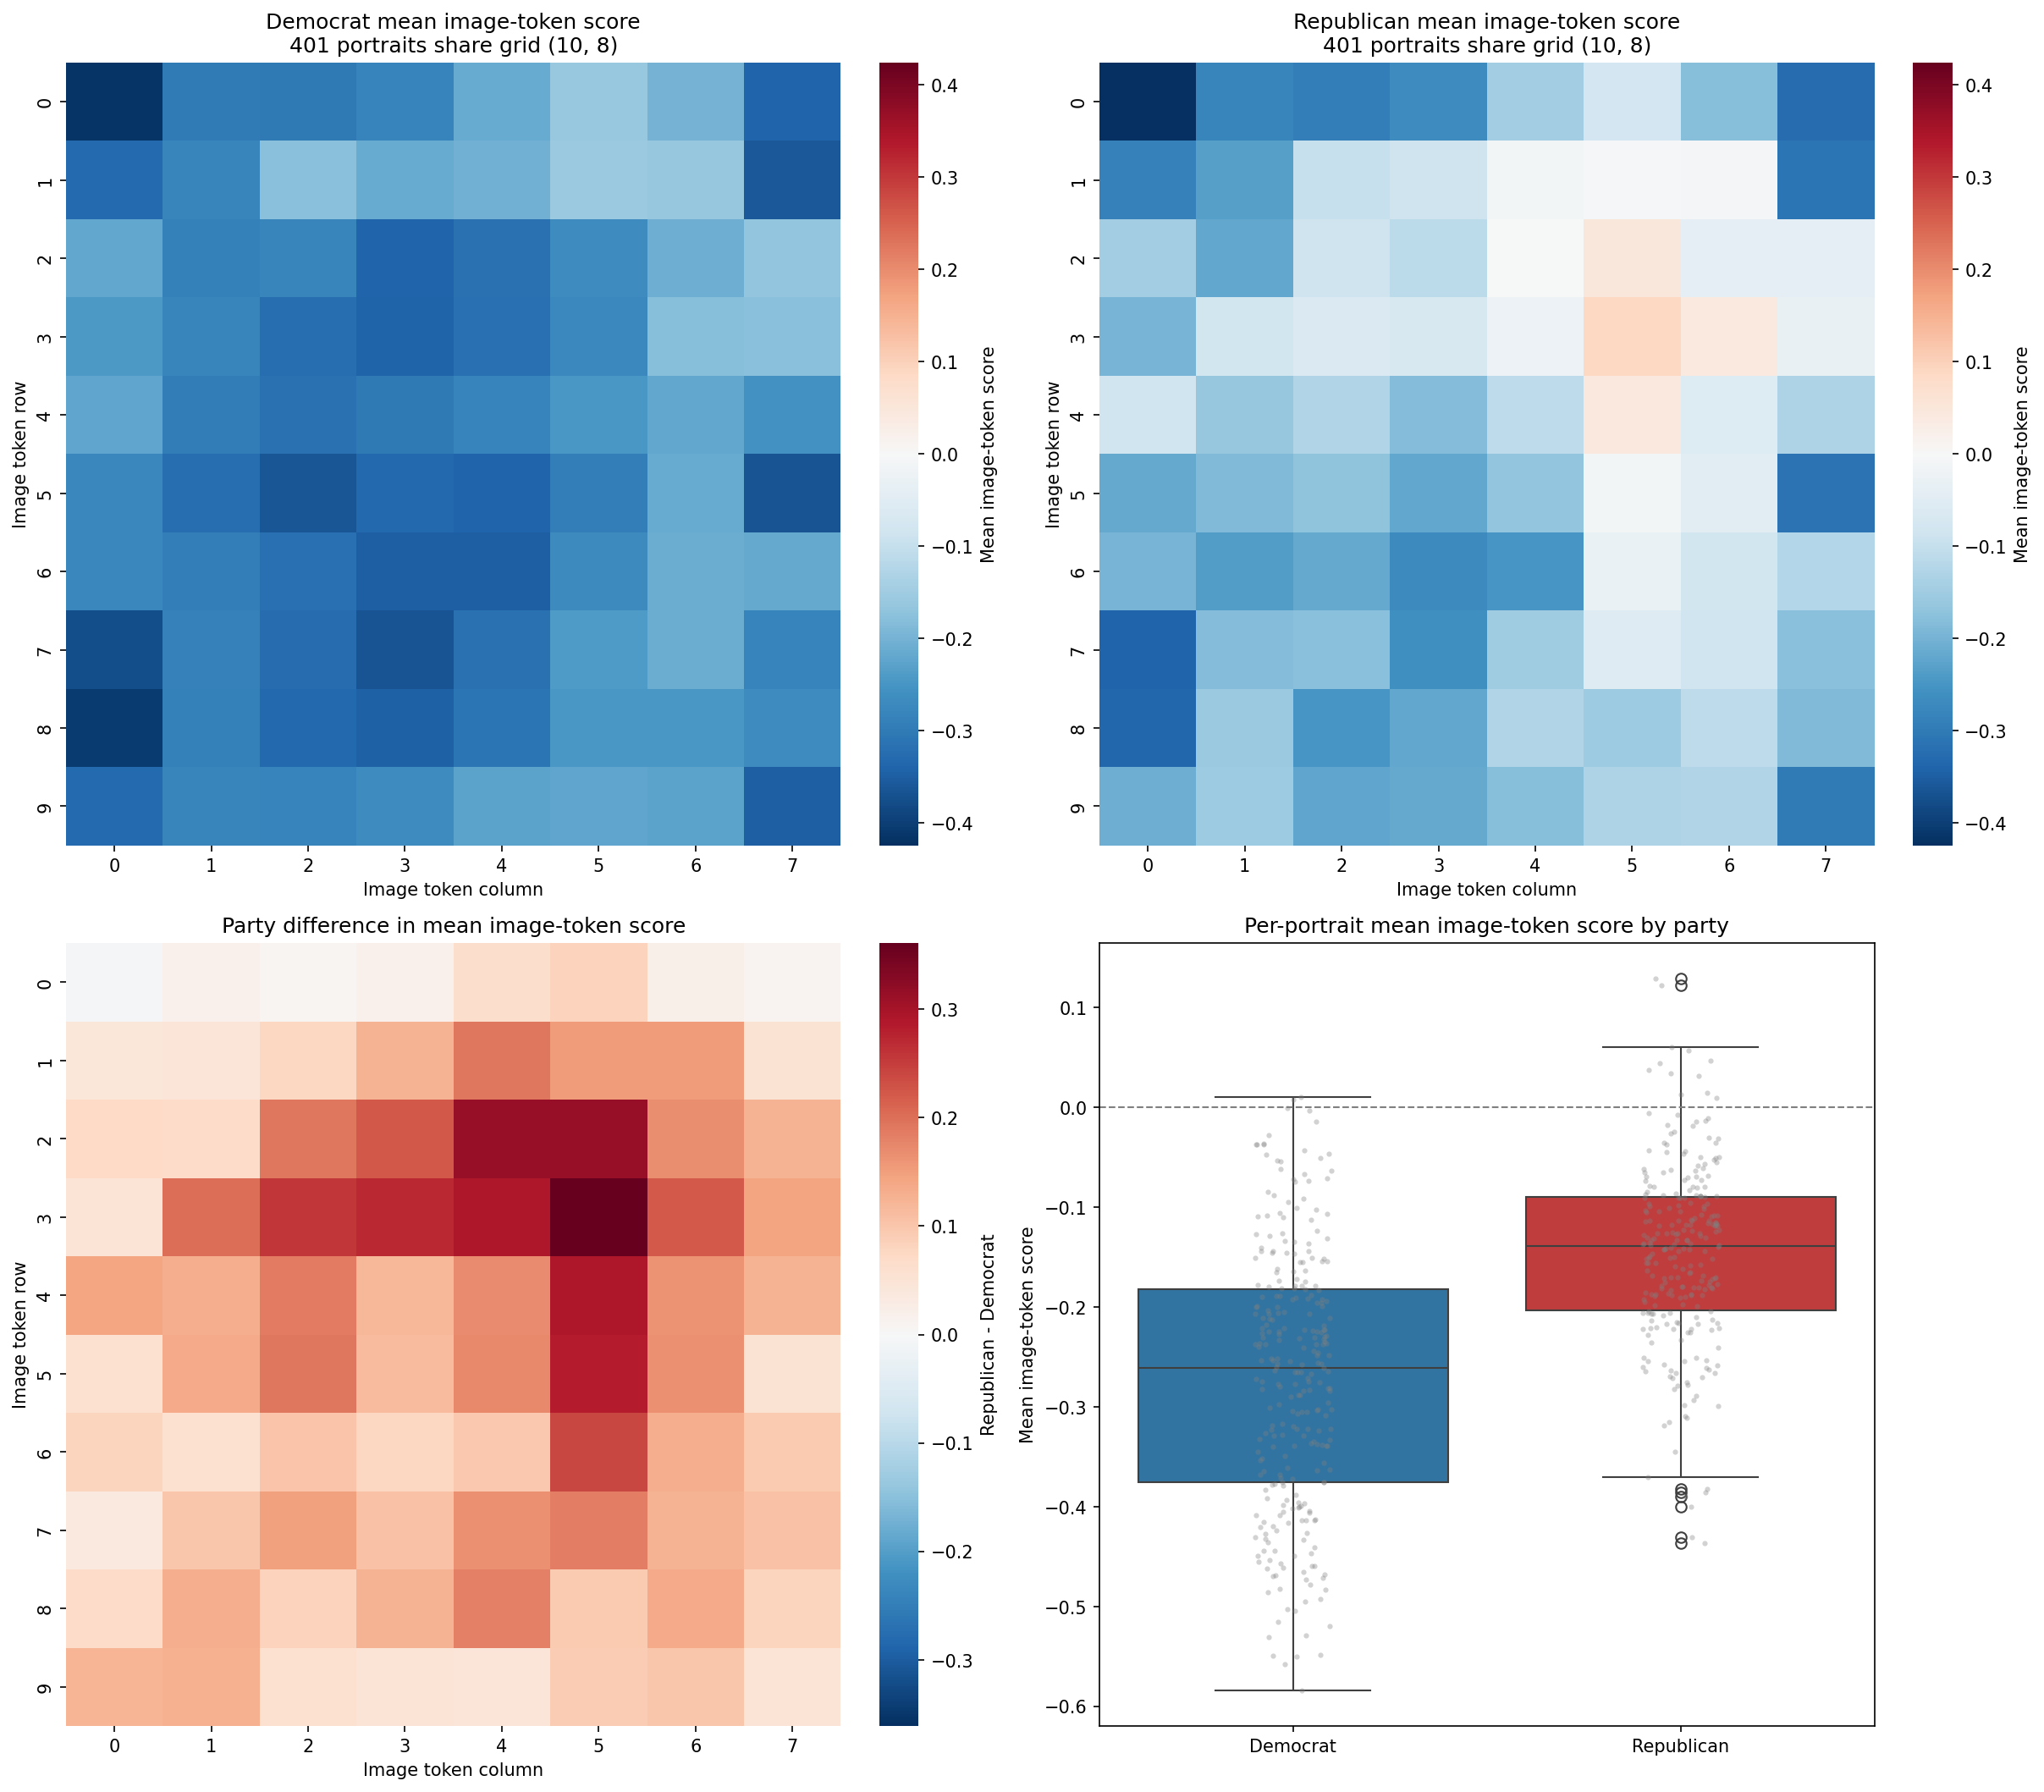

,name,party,nominate_dim1,mean_image_token_score,mean_abs_image_token_score
0,Ruben Gallego,Democrat,-0.418,0.010376,0.214139
1,Chris Pappas,Democrat,-0.237,0.008144,0.192298
2,Richard Blumenthal,Democrat,-0.436,-0.000526,0.225324
3,Mark E. Amodei,Republican,0.387,0.128881,0.327295
4,Matt Gaetz,Republican,0.598,0.121848,0.284719
5,Josh Hawley,Republican,0.781,0.060327,0.220483


In [7]:
party_order = [party for party in ["Democrat", "Republican"] if party in congress_token_scores["party"].unique()]
plot_df = congress_token_scores[congress_token_scores["party"].isin(party_order)].copy()

if plot_df.empty:
    raise RuntimeError("No Democrat/Republican portraits were scored.")

common_grid_counts = Counter(
    record["grid_shape"]
    for record in portrait_token_maps
    if record["party"] in party_order
)
common_grid, common_grid_count = common_grid_counts.most_common(1)[0]
heatmap_records = [
    record
    for record in portrait_token_maps
    if record["party"] in party_order and record["grid_shape"] == common_grid
]

party_heatmaps = {
    party: np.stack([record["heatmap"] for record in heatmap_records if record["party"] == party])
    for party in party_order
}
party_heatmaps = {
    party: values.mean(axis=0)
    for party, values in party_heatmaps.items()
    if len(values) > 0
}

summary_df = (
    plot_df.groupby("party", as_index=False)
    .agg(
        portraits=("bioguide", "count"),
        mean_token_score=("mean_image_token_score", "mean"),
        sem_token_score=("mean_image_token_score", "sem"),
        mean_abs_token_score=("mean_abs_image_token_score", "mean"),
        mean_nominate_dim1=("nominate_dim1", "mean"),
    )
)
display(summary_df)

heatmap_values = [heatmap for heatmap in party_heatmaps.values()]
if len(heatmap_values) == 0:
    raise RuntimeError("Could not build any party-level heatmap from the scored portraits.")

heatmap_limit = max(float(np.abs(heatmap).max()) for heatmap in heatmap_values)
diff_limit = None
if len(party_heatmaps) == 2:
    diff_heatmap = party_heatmaps["Republican"] - party_heatmaps["Democrat"]
    diff_limit = float(np.abs(diff_heatmap).max())

fig, axes = plt.subplots(2, 2, figsize=(16, 14), dpi=150, constrained_layout=True)
axes = axes.flatten()
party_palette = {"Democrat": "#1f77b4", "Republican": "#d62728"}

for ax_idx, party in enumerate(party_order[:2]):
    ax = axes[ax_idx]
    sns.heatmap(
        party_heatmaps[party],
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-heatmap_limit,
        vmax=heatmap_limit,
        cbar_kws={"label": "Mean image-token score"},
    )
    ax.set_title(f"{party} mean image-token score\n{common_grid_count} portraits share grid {common_grid}")
    ax.set_xlabel("Image token column")
    ax.set_ylabel("Image token row")

if len(party_heatmaps) == 2:
    sns.heatmap(
        diff_heatmap,
        ax=axes[2],
        cmap="RdBu_r",
        center=0,
        vmin=-diff_limit,
        vmax=diff_limit,
        cbar_kws={"label": "Republican - Democrat"},
    )
    axes[2].set_title("Party difference in mean image-token score")
    axes[2].set_xlabel("Image token column")
    axes[2].set_ylabel("Image token row")
else:
    axes[2].axis("off")

sns.boxplot(
    data=plot_df,
    x="party",
    y="mean_image_token_score",
    order=party_order,
    palette=party_palette,
    ax=axes[3],
)
sns.stripplot(
    data=plot_df,
    x="party",
    y="mean_image_token_score",
    order=party_order,
    color="gray",
    alpha=0.35,
    size=3,
    ax=axes[3],
)
axes[3].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[3].set_title("Per-portrait mean image-token score by party")
axes[3].set_xlabel("")
axes[3].set_ylabel("Mean image-token score")

plt.show()

representatives = (
    plot_df.sort_values(["party", "mean_image_token_score"], ascending=[True, False])
    .groupby("party")
    .head(3)
    .loc[:, ["name", "party", "nominate_dim1", "mean_image_token_score", "mean_abs_image_token_score"]]
    .reset_index(drop=True)
)
display(representatives)

## Correlation: DW-NOMINATE vs image token scores

,party,n,pearson_r,spearman_rho
0,Democrat,285,0.383049,0.378480
1,Other (328),3,0.813367,0.500000
2,Republican,262,0.172543,0.131137


Overall Pearson r: 0.5373
Overall Spearman rho: 0.5443


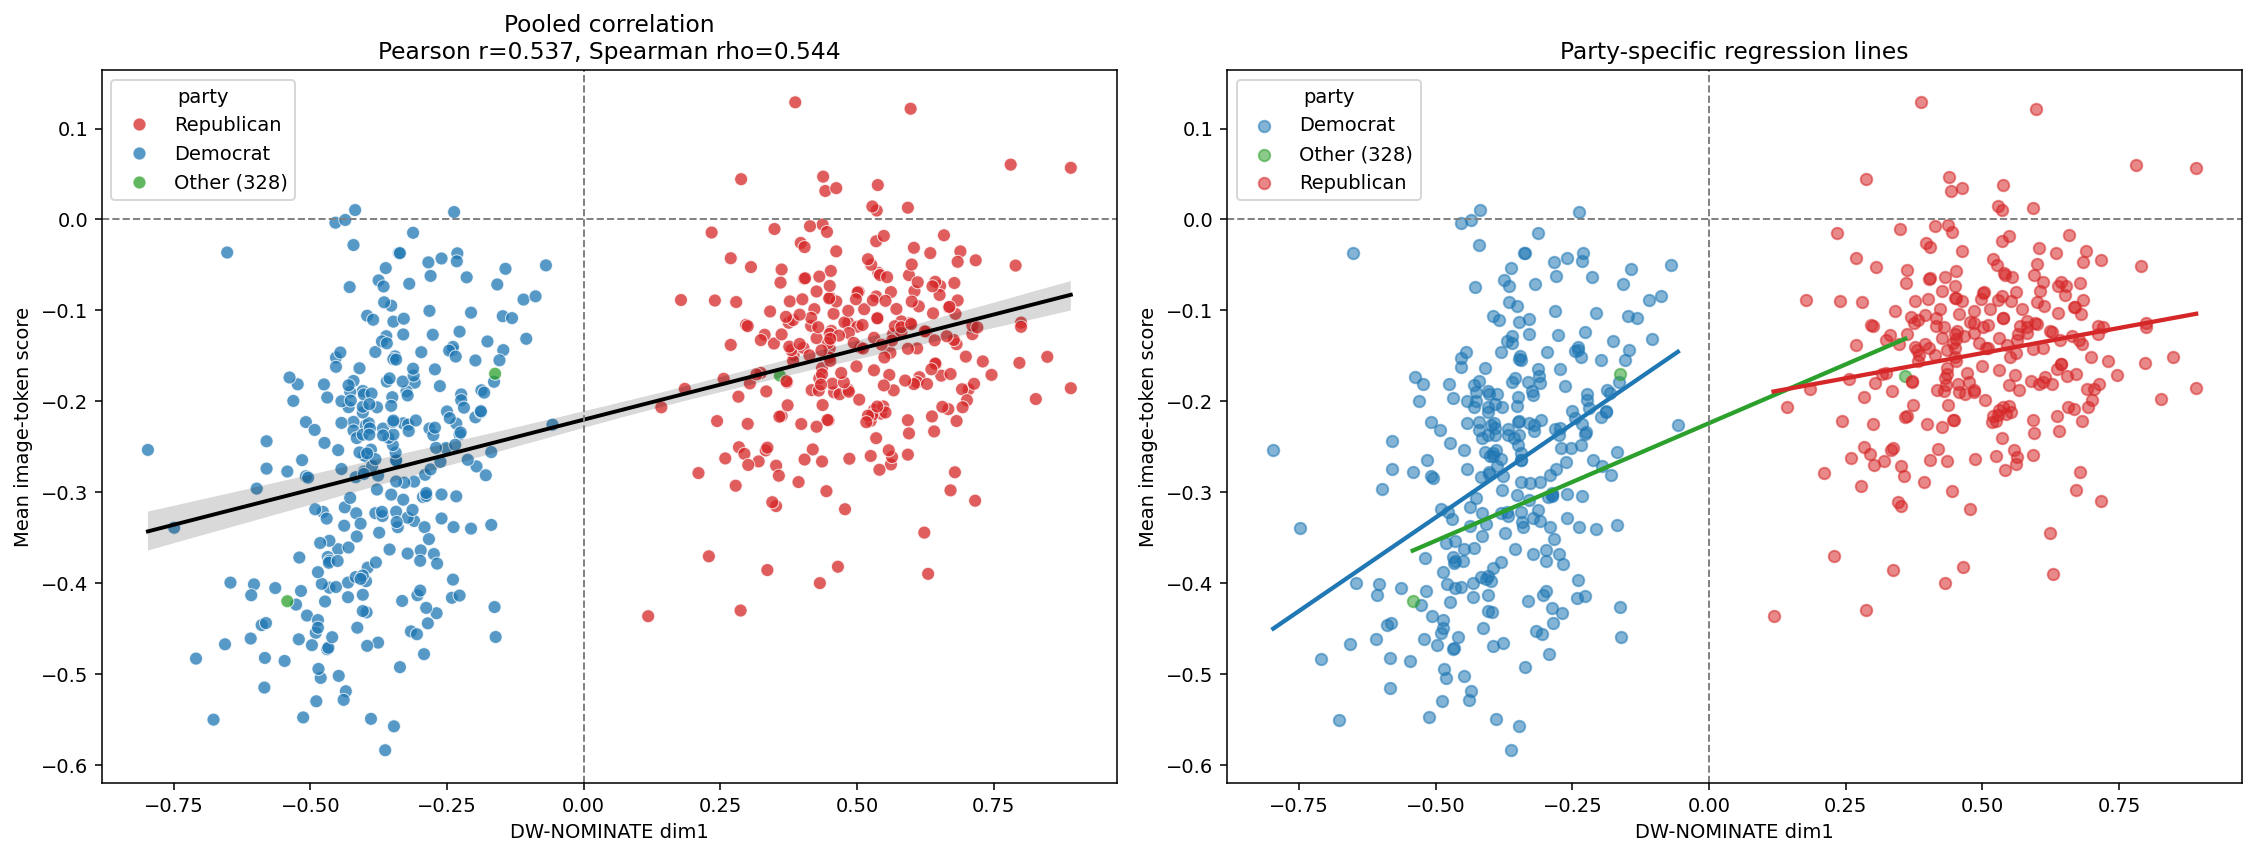

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

if "congress_token_scores" not in globals():
    raise RuntimeError("Run the Congress token scoring cells first to create congress_token_scores.")

corr_input = congress_token_scores.dropna(subset=["nominate_dim1", "mean_image_token_score"]).copy()
if len(corr_input) < 3:
    raise RuntimeError("Need at least 3 portraits with both DW score and token score to compute correlation.")

overall_pearson = float(pearsonr(corr_input["nominate_dim1"], corr_input["mean_image_token_score"]).statistic)
overall_spearman = float(spearmanr(corr_input["nominate_dim1"], corr_input["mean_image_token_score"]).statistic)

party_rows = []
for party, grp in corr_input.groupby("party"):
    n = len(grp)
    if n >= 3:
        p = float(pearsonr(grp["nominate_dim1"], grp["mean_image_token_score"]).statistic)
        s = float(spearmanr(grp["nominate_dim1"], grp["mean_image_token_score"]).statistic)
    else:
        p = np.nan
        s = np.nan
    party_rows.append({"party": party, "n": int(n), "pearson_r": p, "spearman_rho": s})

corr_table = pd.DataFrame(party_rows).sort_values("party").reset_index(drop=True)
display(corr_table)
print(f"Overall Pearson r: {overall_pearson:.4f}")
print(f"Overall Spearman rho: {overall_spearman:.4f}")

party_palette = {"Democrat": "#1f77b4", "Republican": "#d62728", "Other (328)": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=140, constrained_layout=True)

# Panel 1: pooled scatter + pooled regression line
sns.scatterplot(
    data=corr_input,
    x="nominate_dim1",
    y="mean_image_token_score",
    hue="party",
    palette=party_palette,
    alpha=0.75,
    s=45,
    ax=axes[0],
)
sns.regplot(
    data=corr_input,
    x="nominate_dim1",
    y="mean_image_token_score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2.0},
    ax=axes[0],
)
axes[0].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[0].axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[0].set_title(
    f"Pooled correlation\nPearson r={overall_pearson:.3f}, Spearman rho={overall_spearman:.3f}"
)
axes[0].set_xlabel("DW-NOMINATE dim1")
axes[0].set_ylabel("Mean image-token score")

# Panel 2: party-specific regressions
for party, grp in corr_input.groupby("party"):
    color = party_palette.get(party, None)
    if len(grp) >= 2:
        sns.regplot(
            data=grp,
            x="nominate_dim1",
            y="mean_image_token_score",
            scatter=True,
            ci=None,
            scatter_kws={"alpha": 0.55, "s": 35},
            line_kws={"linewidth": 2.2},
            color=color,
            ax=axes[1],
            label=party,
        )
    else:
        axes[1].scatter(grp["nominate_dim1"], grp["mean_image_token_score"], color=color, alpha=0.7, s=35, label=party)

axes[1].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[1].set_title("Party-specific regression lines")
axes[1].set_xlabel("DW-NOMINATE dim1")
axes[1].set_ylabel("Mean image-token score")
axes[1].legend(loc="best", title="party")

plt.show()